In [1]:

#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [2]:
from sklearn.metrics import confusion_matrix as cm_function

def compute_metrics(y_true, y_pred):
    """Return accuracy, sensitivity, specificity, F1 as percentages."""
    cm = cm_function(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    acc         = (TP + TN) / (TP + TN + FP + FN) * 100
    sensitivity = TP / (TP + FN) * 100 if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) * 100 if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP)       if (TP + FP) > 0 else 0.0
    recall      = TP / (TP + FN)       if (TP + FN) > 0 else 0.0
    f1          = 2 * precision * recall / (precision + recall) * 100 if (precision + recall) > 0 else 0.0
    return acc, sensitivity, specificity, f1

In [3]:
 #Load
#2
#df = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic - Copy.csv")
df = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:", df.isnull().sum().sum())
#print("\nDuplicates:", df.duplicated().sum())



Shape: (2111, 18)

Columns: ['ID', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Missing Values: 0


In [4]:
# Create Fit / Not Fit column
#3
df["is_fit"] = df["NObeyesdad"].apply(lambda x: 1 if x == "Normal_Weight" else 0)
df.drop(columns=["NObeyesdad"], inplace=True)
print("\nFit (1)    :", df["is_fit"].sum())
print("Not Fit (0):", (df["is_fit"] == 0).sum())

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=["is_fit", "ID"])
y = df["is_fit"]

num_cols = X.select_dtypes(include=["float64", "int64"]).columns
X[num_cols] = StandardScaler().fit_transform(X[num_cols])
print("\nStandardized numeric columns:", list(num_cols))

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Fit (1)    : 287
Not Fit (0): 1824

Standardized numeric columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']

Train size: 1688
Test size : 423


In [5]:
#SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE (train):", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After  SMOTE (train):", Counter(y_train))
print("Test set (unchanged):", Counter(y_test))

Before SMOTE (train): Counter({0: 1459, 1: 229})
After  SMOTE (train): Counter({0: 1459, 1: 1459})
Test set (unchanged): Counter({0: 365, 1: 58})


Accuracy                    : 81.80%
Sensitivity (Fit recall)    : 77.59%
Specificity (Not-Fit recall): 82.47%
F1 score (Fit)              : 53.89%


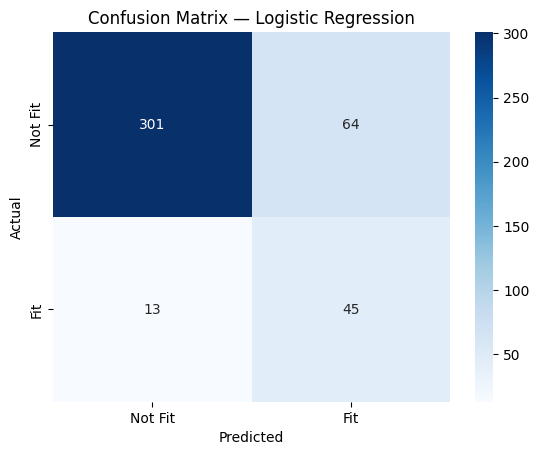

In [6]:

#Baseline model
# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

acc_m, sens_m, spec_m, f1_m = compute_metrics(y_test, y_pred)
print(f"Accuracy                    : {acc_m:.2f}%")
print(f"Sensitivity (Fit recall)    : {sens_m:.2f}%")
print(f"Specificity (Not-Fit recall): {spec_m:.2f}%")
print(f"F1 score (Fit)              : {f1_m:.2f}%")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fit", "Fit"],
            yticklabels=["Not Fit", "Fit"])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Selected features: ['CAEC', 'Weight', 'NCP', 'SMOKE', 'FAVC', 'Gender', 'family_history_with_overweight', 'Height']
Accuracy with 8 features: 84.63%
Accuracy with all 16 features: 81.80%


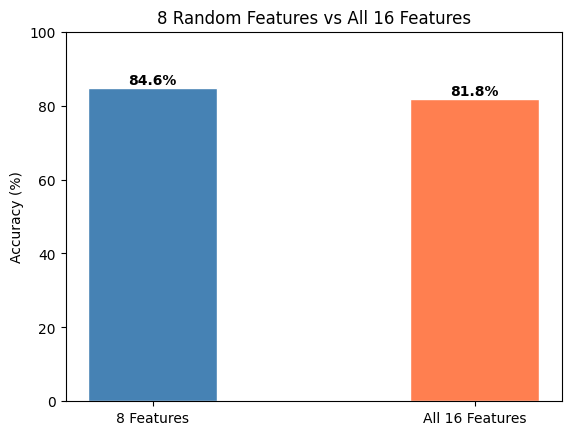

In [7]:
# Randomly pick features
#5
random_8 = [str(f) for f in np.random.choice(X.columns.tolist(), size=8, replace=False)]
print("Selected features:", random_8)

model_8 = LogisticRegression(max_iter=1000, random_state=42)
model_8.fit(X_train[random_8], y_train)

# Accuracy
acc_8 = accuracy_score(y_test, model_8.predict(X_test[random_8]))
print(f"Accuracy with {len(random_8)} features: {acc_8 * 100:.2f}%")

acc_full = accuracy_score(y_test, model.predict(X_test))
n_full = X.shape[1]
print(f"Accuracy with all {n_full} features: {acc_full * 100:.2f}%")

# Plotting
plt.bar([f"{len(random_8)} Features", f"All {n_full} Features"],
        [acc_8 * 100, acc_full * 100],
        color=["steelblue", "coral"], edgecolor="white", width=0.4)
plt.title(f"{len(random_8)} Random Features vs All {n_full} Features")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for i, val in enumerate([acc_8 * 100, acc_full * 100]):
    plt.text(i, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")
plt.show()

New variable added: CALC
All 9 features: ['CAEC', 'Weight', 'NCP', 'SMOKE', 'FAVC', 'Gender', 'family_history_with_overweight', 'Height', 'CALC']

Accuracy with 8 features: 84.63%
Accuracy with 9 features: 84.87%


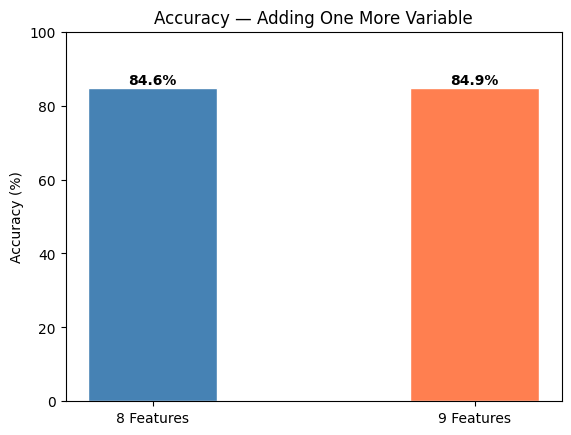

In [8]:
# Add 1 new random variable
#6
remaining = [f for f in X.columns.tolist() if f not in random_8]
new_var = str(np.random.choice(remaining))
print("New variable added:", new_var)

random_9 = random_8 + [new_var]
print(f"All {len(random_9)} features:", random_9)

model_9 = LogisticRegression(max_iter=1000, random_state=42)
model_9.fit(X_train[random_9], y_train)

acc_9 = accuracy_score(y_test, model_9.predict(X_test[random_9]))
print(f"\nAccuracy with {len(random_8)} features: {acc_8 * 100:.2f}%")
print(f"Accuracy with {len(random_9)} features: {acc_9 * 100:.2f}%")

labels = [f"{len(random_8)} Features", f"{len(random_9)} Features"]
values = [acc_8 * 100, acc_9 * 100]
plt.bar(labels, values,
        color=["steelblue", "coral"],
        edgecolor="white", width=0.4)
plt.title("Accuracy — Adding One More Variable")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for i, val in enumerate(values):
    plt.text(i, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")
plt.show()

Starting with 1 random features: ['NCP']
Step 0 |  1 features | Accuracy: 34.52% | ['NCP']
  +1   |  2 features | Added: FCVC                                | Accuracy: 58.63%
  +1   |  3 features | Added: TUE                                 | Accuracy: 55.08%
  +1   |  4 features | Added: Gender                              | Accuracy: 58.87%
  +1   |  5 features | Added: CALC                                | Accuracy: 57.92%
  +1   |  6 features | Added: SCC                                 | Accuracy: 64.54%
  +1   |  7 features | Added: CH2O                                | Accuracy: 61.47%
  +1   |  8 features | Added: Height                              | Accuracy: 63.36%
  +1   |  9 features | Added: CAEC                                | Accuracy: 73.29%
  +1   | 10 features | Added: Weight                              | Accuracy: 82.74%
  +1   | 11 features | Added: FAF                                 | Accuracy: 83.69%
  +1   | 12 features | Added: SMOKE                        

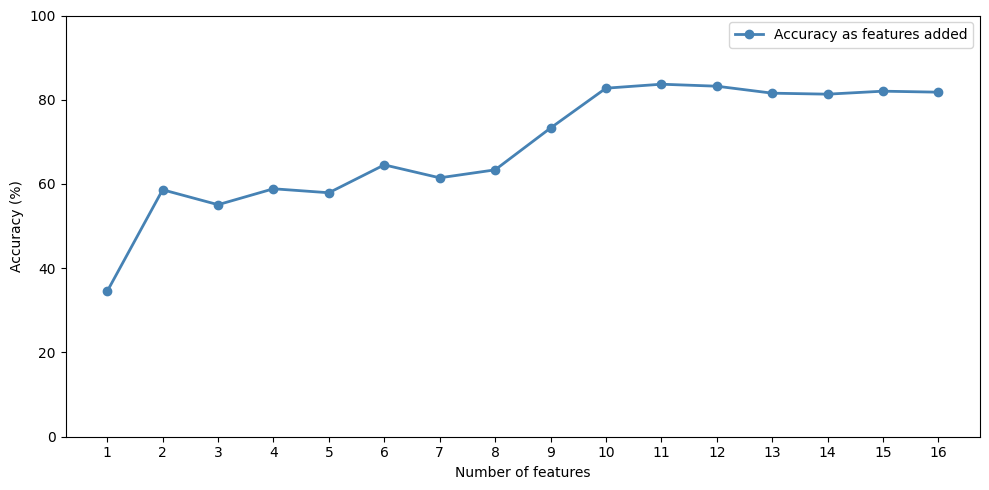

In [9]:
# 7
# Add +1,+1
all_feats  = X.columns.tolist()
n_full     = X.shape[1]

start_size = 1
current    = [str(f) for f in np.random.choice(all_feats, size=start_size, replace=False)]
remaining  = [str(f) for f in all_feats if f not in current]
np.random.shuffle(remaining)

print(f"Starting with {start_size} random features: {current}")


step_sizes = []
step_accs  = []

m = LogisticRegression(max_iter=1000, random_state=42)
m.fit(X_train[current], y_train)
acc = accuracy_score(y_test, m.predict(X_test[current])) * 100
step_sizes.append(len(current))
step_accs.append(acc)
print(f"Step 0 | {len(current):2d} features | Accuracy: {acc:.2f}% | {current}")

for feat in remaining:
    current.append(feat)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_train[current], y_train)
    acc = accuracy_score(y_test, m.predict(X_test[current])) * 100
    step_sizes.append(len(current))
    step_accs.append(acc)
    print(f"  +1   | {len(current):2d} features | Added: {feat:35s} | Accuracy: {acc:.2f}%")

step_sizes = np.array(step_sizes)
step_accs  = np.array(step_accs)


sat_size = step_sizes[-1]


plt.figure(figsize=(10, 5))
plt.plot(step_sizes, step_accs, marker="o", color="steelblue",
         linewidth=2, label="Accuracy as features added")

plt.xlabel("Number of features")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(step_sizes)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# 8



all_feats2 = X.columns.tolist()
np.random.shuffle(all_feats2)

used        = []
sizes2      = []
accs2       = []

draw = 1
while len(all_feats2) > 0:
    pick_size = np.random.randint(1, len(all_feats2) + 1)
    picked    = all_feats2[:pick_size]
    all_feats2 = all_feats2[pick_size:]

    used = used + picked

    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_train[used], y_train)
    acc = accuracy_score(y_test, m.predict(X_test[used])) * 100

    sizes2.append(len(used))
    accs2.append(acc)
    print(f"Draw {draw:2d} | Added {len(picked):2d} vars: {picked}")
    print(f"         Total {len(used):2d} variables used | Accuracy: {acc:.2f}%\n")
    draw += 1

sizes2 = np.array(sizes2)
accs2  = np.array(accs2)



# Plot
plt.figure(figsize=(10, 5))
plt.plot(sizes2, accs2, marker="o", color="mediumseagreen",
         linewidth=2, label="Accuracy (non-repeatable draws)"
plt.xlabel("Total number of variables used so far")
plt.ylabel("Accuracy (%)")
plt.title("Approach 2: Random Draws, Non-Repeatable Variables\n")
plt.ylim(0, 100)
plt.xticks(sizes2)
plt.legend()
plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (1165283837.py, line 37)

In [ ]:
#9


all_feats3 = X.columns.tolist()
n_draws    = 10
used3      = []
sizes3     = []
accs3      = []

print(f"All 16 variables: {all_feats3}\n")

for draw in range(1, n_draws + 1):
    pick_size = np.random.randint(1, len(all_feats3) + 1)
    picked    = [str(f) for f in np.random.choice(all_feats3, size=pick_size, replace=False)]

    new_vars = [f for f in picked if f not in used3]
    used3    = used3 + new_vars

    if len(used3) == 0:
        continue

    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_train[used3], y_train)
    acc = accuracy_score(y_test, m.predict(X_test[used3])) * 100

    sizes3.append(len(used3))
    accs3.append(acc)
    print(f"Draw {draw:2d} | Picked {len(picked):2d} vars: {picked}")
    print(f"         New vars added: {new_vars if new_vars else 'none (all repeated)'}")
    print(f"         Total unique {len(used3):2d} variables | Accuracy: {acc:.2f}%\n")

sizes3 = np.array(sizes3)
accs3  = np.array(accs3)



# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sizes3) + 1), accs3, marker="o", color="purple",
         linewidth=2, label="Accuracy (repeatable draws)")

plt.xlabel("Draw number")
plt.ylabel("Accuracy (%)")
plt.title("Approach 3: Random Draws, Repeatable Variables (all draws)")
plt.ylim(0, 100)
plt.xticks(range(1, len(sizes3) + 1))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 10
# train test 80/20



X_tr = X_train.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)
n_train = len(X_tr)

percentages = list(range(10, 101, 10))
sizes_r     = []
accs_r      = []

print(f"Total training patients available: {n_train}")
print(f"Test set size (fixed): {len(X_test)}\n")

for pct in percentages:
    size = max(int(pct / 100 * n_train), 10)
    idx  = np.random.choice(n_train, size=size, replace=False)
    Xb   = X_tr.iloc[idx]
    yb   = y_tr.iloc[idx]

    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xb, yb)

    acc = accuracy_score(y_test, m.predict(X_test)) * 100
    sizes_r.append(size)
    accs_r.append(acc)
    print(f"{pct:3d}% | {size:4d} patients | Accuracy: {acc:.2f}%")

sizes_r = np.array(sizes_r)
accs_r  = np.array(accs_r)



# Plot
plt.figure(figsize=(10, 5))
plt.plot(sizes_r, accs_r, marker="o", color="steelblue",
         linewidth=2, label="Accuracy vs patients used")

plt.xlabel("Number of patients used for training")
plt.ylabel("Accuracy (%)")

ax = plt.gca()
ax.set_xticks(sizes_r)
ax.set_xticklabels([f"{p}%\n({s})" for p, s in zip(percentages, sizes_r)],
                   fontsize=8)

plt.title("Row-Based Saturation: How many patients do we actually need?\n")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Saved results to accuracy_curves.csv
           1_vars  2_vars  3_vars  4_vars  5_vars  6_vars  7_vars  8_vars  \
repeat_1    55.08   57.68   61.70   59.10   59.81   81.09   81.09   81.56   
repeat_2    59.10   74.94   74.94   78.96   80.14   80.61   81.09   79.91   
repeat_3    55.08   81.80   81.32   86.05   85.34   84.40   85.11   84.87   
repeat_4    69.74   68.56   83.22   82.51   76.83   81.56   82.27   80.85   
repeat_5    81.32   82.27   84.87   84.87   84.40   85.11   84.87   84.63   
repeat_6    83.22   83.45   81.56   79.67   77.54   82.03   81.32   81.56   
repeat_7    47.28   52.72   70.69   82.03   81.80   81.56   81.56   80.38   
repeat_8    59.34   60.52   75.18   73.76   74.00   73.05   76.12   84.16   
repeat_9    83.22   83.22   83.22   82.51   82.74   80.14   78.49   78.96   
repeat_10   42.32   47.28   42.79   82.27   82.51   83.22   82.27   84.16   
repeat_11   83.92   74.94   74.94   75.41   74.94   76.60   77.54   76.60   
repeat_12   28.37   29.08   54.85   59.

/tmp/ipykernel_1149/3822099597.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


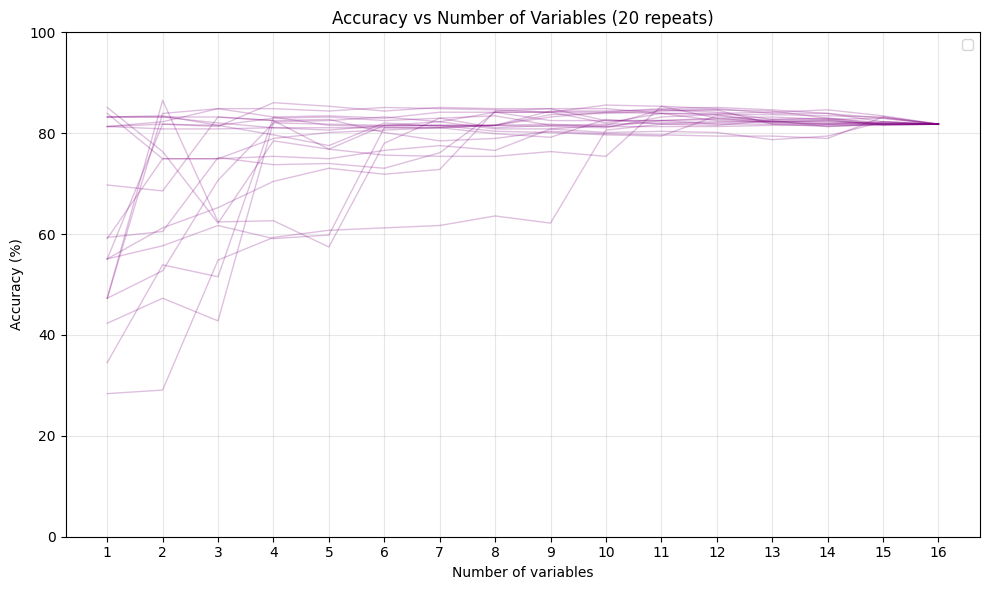

In [11]:
#

all_feats  = X.columns.tolist()
n_features = len(all_feats)
n_repeats  = 20

results = np.zeros((n_repeats, n_features))

rng = np.random.default_rng(42)

for r in range(n_repeats):
    order = rng.permutation(all_feats)
    for k in range(n_features):
        feats = list(order[:k + 1])
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(X_train[feats], y_train)
        acc = accuracy_score(y_test, m.predict(X_test[feats])) * 100
        results[r, k] = acc

feature_counts = np.arange(1, n_features + 1)
results_df = pd.DataFrame(
    results,
    columns=[f"{k}_vars" for k in feature_counts],
    index=[f"repeat_{r+1}" for r in range(n_repeats)]
)
results_df.to_csv("accuracy_curves.csv")
print("Saved results to accuracy_curves.csv")
print(results_df.round(2))

plt.figure(figsize=(10, 6))
for r in range(n_repeats):
    plt.plot(feature_counts, results[r], color="purple", alpha=0.25, linewidth=1)

mean_curve = results.mean(axis=0)


plt.xlabel("Number of variables")
plt.ylabel("Accuracy (%)")
plt.title(f"Accuracy vs Number of Variables ({n_repeats} repeats)")
plt.xticks(feature_counts)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  Added FCVC                 →  1 vars → Accuracy: 55.08%
  Added MTRANS               →  2 vars → Accuracy: 57.68%
  Added SCC                  →  3 vars → Accuracy: 61.70%
  Added CH2O                 →  4 vars → Accuracy: 59.10%
  Added SMOKE                →  5 vars → Accuracy: 59.81%
  Added Weight               →  6 vars → Accuracy: 81.09%
  Added Gender               →  7 vars → Accuracy: 81.09%
  Added NCP                  →  8 vars → Accuracy: 81.56%
  Added FAF                  →  9 vars → Accuracy: 81.80%
  Added FAVC                 → 10 vars → Accuracy: 81.32%
  Added Height               → 11 vars → Accuracy: 82.51%
  Added family_history_with_overweight → 12 vars → Accuracy: 82.74%
  Added CALC                 → 13 vars → Accuracy: 82.74%
  Added Age                  → 14 vars → Accuracy: 82.98%
  Added TUE                  → 15 vars → Accuracy: 82.03%
  Added CAEC                 → 16 vars → Accuracy: 81.80%
  Added CH2O                 →  1 vars → Accuracy: 59.10%
  Ad

/tmp/ipykernel_1149/3685961183.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


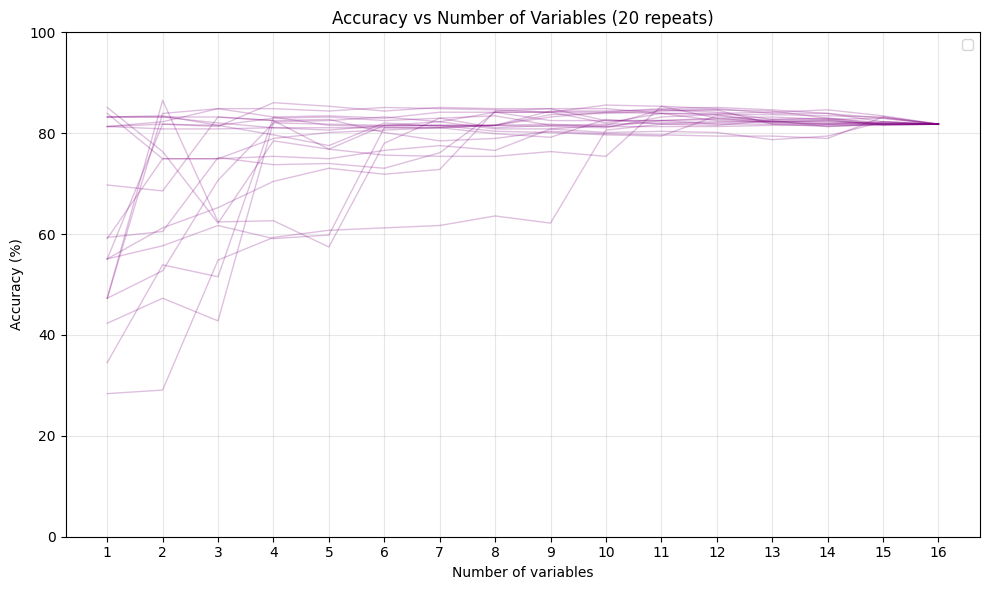

/tmp/ipykernel_1149/3685961183.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


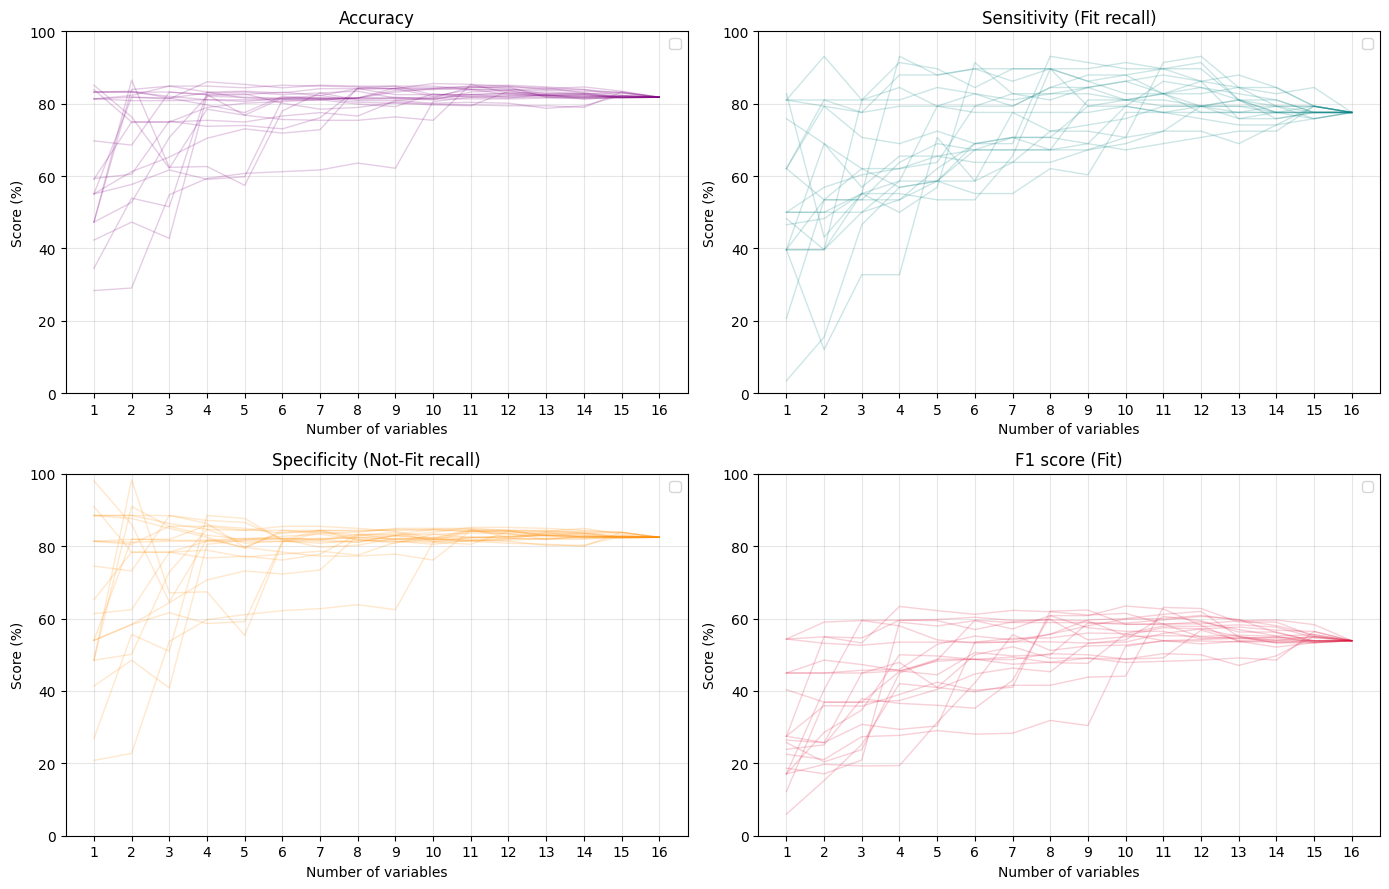

In [12]:
# 20 REPEATS

all_feats  = X.columns.tolist()
n_features = len(all_feats)
n_repeats  = 20

acc_res  = np.zeros((n_repeats, n_features))
sens_res = np.zeros((n_repeats, n_features))
spec_res = np.zeros((n_repeats, n_features))
f1_res   = np.zeros((n_repeats, n_features))

rng = np.random.default_rng(42)

for r in range(n_repeats):
  order = rng.permutation(all_feats)
  for k in range(n_features):
    feats = list(order[:k + 1])
    m.fit(X_train[feats], y_train)
    y_pred_r = m.predict(X_test[feats])
    acc, sens, spec, f1 = compute_metrics(y_test, y_pred_r)
    acc_res[r, k]  = acc
    sens_res[r, k] = sens
    spec_res[r, k] = spec
    f1_res[r, k]   = f1
    print(f"  Added {order[k]:20s} → {k+1:2d} vars → Accuracy: {acc:.2f}%")

feature_counts = np.arange(1, n_features + 1)

acc_df = pd.DataFrame(
    acc_res,
    columns=[f"{k}_vars" for k in feature_counts],
    index=[f"repeat_{r+1}" for r in range(n_repeats)]
)
acc_df.to_csv("accuracy_curves.csv")
print(f"\nSaved accuracy_curves.csv")
print(acc_df.round(2))

plt.figure(figsize=(10, 6))
for r in range(n_repeats):
    plt.plot(feature_counts, acc_res[r], color="purple", alpha=0.25, linewidth=1)

plt.xlabel("Number of variables")
plt.ylabel("Accuracy (%)")
plt.title(f"Accuracy vs Number of Variables ({n_repeats} repeats)")
plt.xticks(feature_counts)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

metrics = [("Accuracy", acc_res, "purple"),
           ("Sensitivity (Fit recall)", sens_res, "teal"),
           ("Specificity (Not-Fit recall)", spec_res, "darkorange"),
           ("F1 score (Fit)", f1_res, "crimson")]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, arr, colour) in zip(axes.ravel(), metrics):
    for r in range(n_repeats):
        ax.plot(feature_counts, arr[r], color=colour, alpha=0.2, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Number of variables")
    ax.set_ylabel("Score (%)")
    ax.set_xticks(feature_counts)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

Individual Variable Performance

  Gender                              | Acc: 47.28%
  Age                                 | Acc: 56.97%
  Height                              | Acc: 59.34%
  Weight                              | Acc: 81.32%
  family_history_with_overweight      | Acc: 83.22%
  FAVC                                | Acc: 84.40%
  FCVC                                | Acc: 55.08%
  NCP                                 | Acc: 34.52%
  CAEC                                | Acc: 83.92%
  SMOKE                               | Acc: 85.11%
  CH2O                                | Acc: 59.10%
  SCC                                 | Acc: 86.52%
  FAF                                 | Acc: 57.92%
  TUE                                 | Acc: 42.32%
  CALC                                | Acc: 69.74%
  MTRANS                              | Acc: 28.37%

--- Ranking (best individual accuracy) ---
   1. SCC                                 | Acc: 86.52%
   2. SMOKE                        

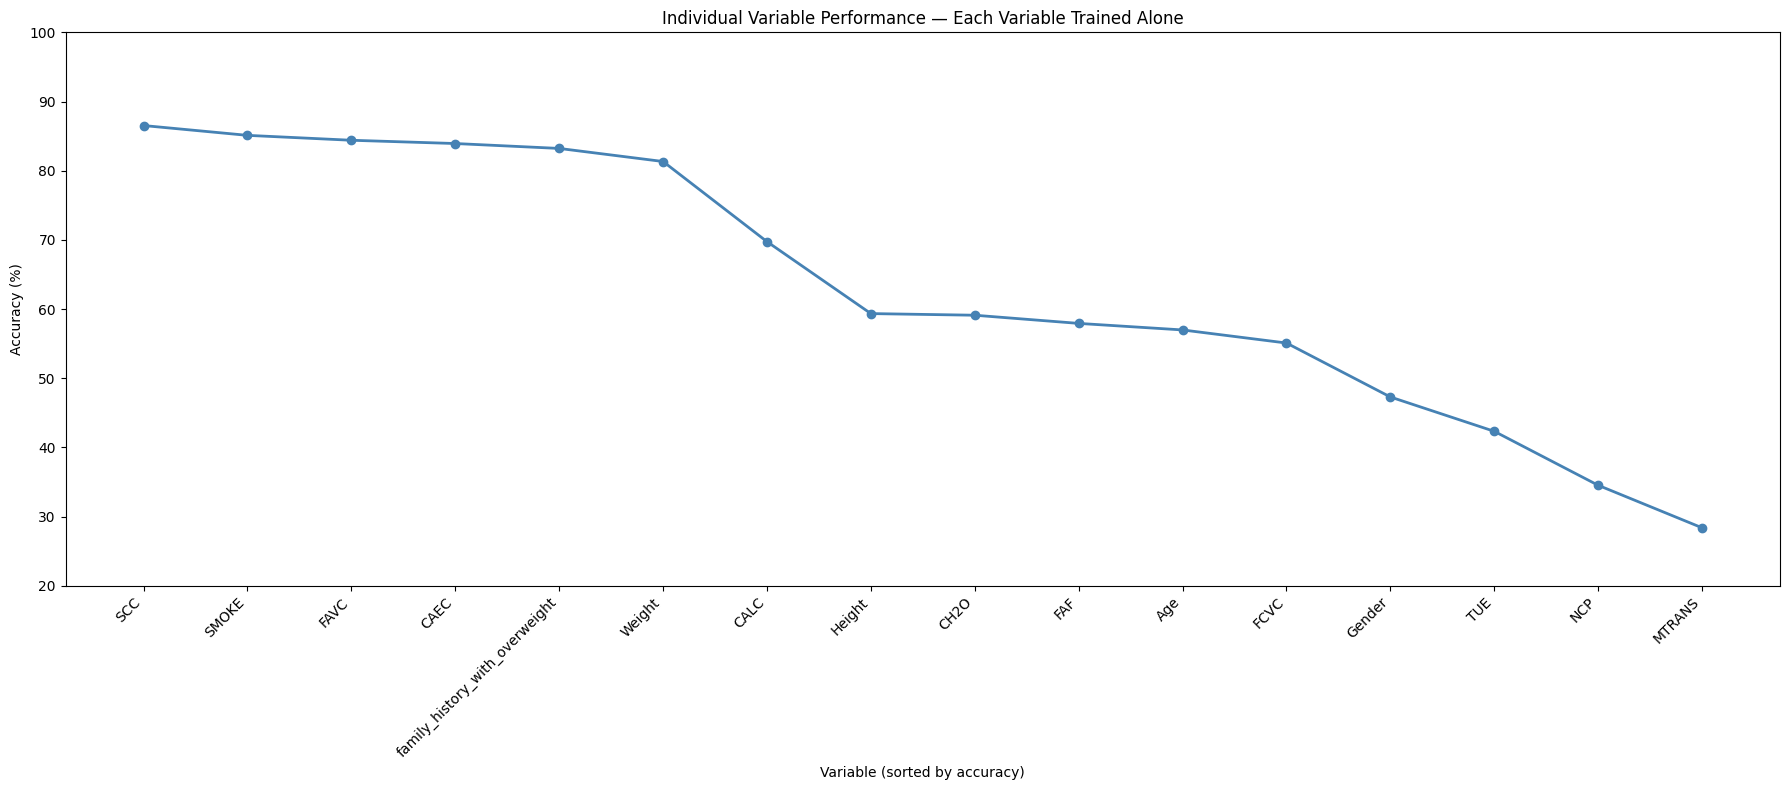

In [13]:



all_feats = X_train.columns.tolist()

feat_names = []
feat_accs  = []

print("Individual Variable Performance\n")

for feat in all_feats:
    scaler = StandardScaler()
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(scaler.fit_transform(X_train[[feat]]), y_train)
    acc = accuracy_score(y_test, m.predict(scaler.transform(X_test[[feat]]))) * 100

    feat_names.append(feat)
    feat_accs.append(acc)
    print(f"  {feat:35s} | Acc: {acc:.2f}%")

sorted_idx   = np.argsort(feat_accs)[::-1]
sorted_names = [feat_names[i] for i in sorted_idx]
sorted_accs  = [feat_accs[i] for i in sorted_idx]

print("\n--- Ranking (best individual accuracy) ---")
for rank, i in enumerate(sorted_idx, 1):
    print(f"  {rank:2d}. {feat_names[i]:35s} | Acc: {feat_accs[i]:.2f}%")

# Plot
plt.figure(figsize=(18, 8))
plt.plot(sorted_names, sorted_accs, marker="o", color="steelblue", linewidth=2)
plt.xlabel("Variable (sorted by accuracy)")
plt.ylabel("Accuracy (%)")
plt.title("Individual Variable Performance — Each Variable Trained Alone")
plt.xticks(rotation=45, ha="right")
plt.ylim(20, 100)
plt.tight_layout()
plt.show()


  Easy 
   1. family_history_with_overweight      | Acc: 83.22%
   2. Weight                              | Acc: 81.32%
   3. Height                              | Acc: 59.34%
   4. Age                                 | Acc: 56.97%
   5. Gender                              | Acc: 47.28%

  Mid 
   1. SCC                                 | Acc: 86.52%
   2. SMOKE                               | Acc: 85.11%
   3. FAVC                                | Acc: 84.40%
   4. CAEC                                | Acc: 83.92%
   5. CALC                                | Acc: 69.74%
   6. MTRANS                              | Acc: 28.37%

  Complex 
   1. CH2O                                | Acc: 59.10%
   2. FAF                                 | Acc: 57.92%
   3. FCVC                                | Acc: 55.08%
   4. TUE                                 | Acc: 42.32%
   5. NCP                                 | Acc: 34.52%
  Step  1 | Added: family_history_with_overweight      | Total vars:  1 | A

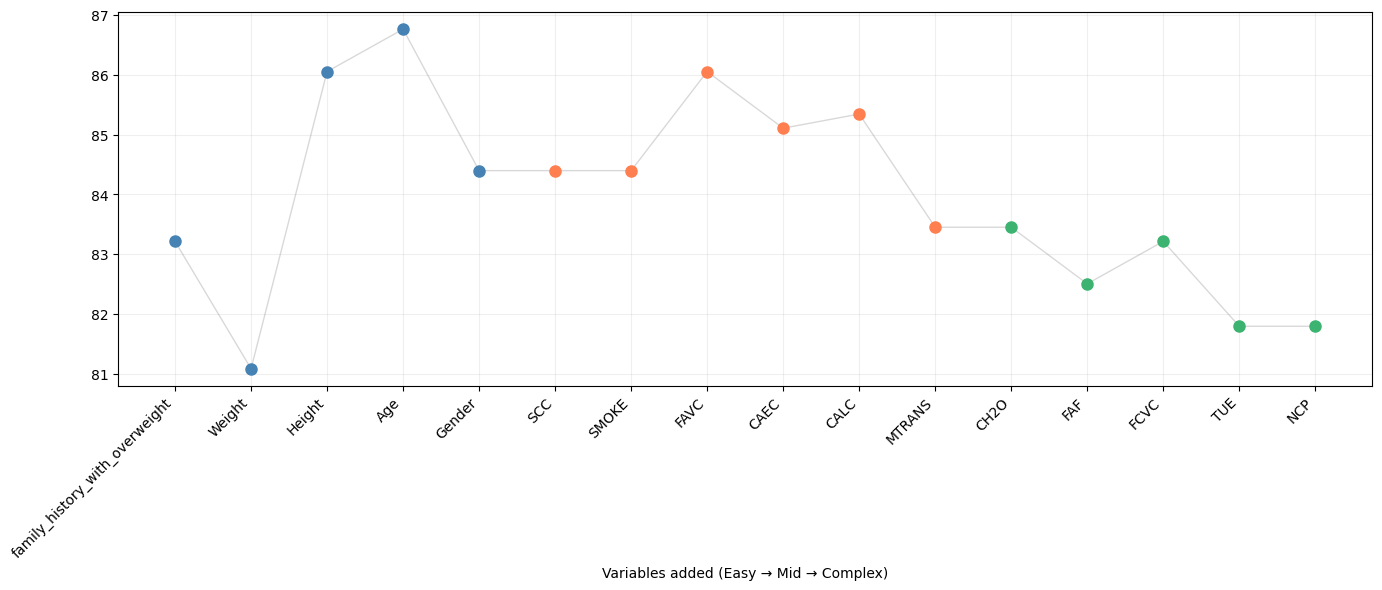

In [14]:



easy = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight']
mid = ['SMOKE', 'SCC', 'MTRANS', 'FAVC', 'CAEC', 'CALC']
complex_vars = ['NCP', 'FCVC', 'CH2O', 'FAF', 'TUE']

groups = {
    'Easy ': easy,
    'Mid ': mid,
    'Complex ': complex_vars
}


group_results = {}

for group_name, variables in groups.items():
    print(f"\n  {group_name}")

    names = []
    accs = []

    for feat in variables:
        scaler = StandardScaler()
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(scaler.fit_transform(X_train[[feat]]), y_train)
        acc = accuracy_score(y_test, m.predict(scaler.transform(X_test[[feat]]))) * 100
        names.append(feat)
        accs.append(acc)

    sorted_idx = np.argsort(accs)[::-1]
    sorted_names = [names[i] for i in sorted_idx]
    sorted_accs = [accs[i] for i in sorted_idx]

    for rank, i in enumerate(sorted_idx, 1):
        print(f"  {rank:2d}. {names[i]:35s} | Acc: {accs[i]:.2f}%")

    group_results[group_name] = (sorted_names, sorted_accs)




selected = []
cum_accs = []
cum_labels = []
cum_groups = []

group_colors = ['steelblue', 'coral', 'mediumseagreen']

for group_idx, (group_name, (sorted_names, sorted_accs)) in enumerate(group_results.items()):
    for feat in sorted_names:
        selected.append(feat)

        scaler = StandardScaler()
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(scaler.fit_transform(X_train[selected]), y_train)
        acc = accuracy_score(y_test, m.predict(scaler.transform(X_test[selected]))) * 100

        cum_accs.append(acc)
        cum_labels.append(feat)
        cum_groups.append(group_idx)

        print(f"  Step {len(selected):2d} | Added: {feat:35s} | Total vars: {len(selected):2d} | Acc: {acc:.2f}%")



x = np.arange(1, len(cum_accs) + 1)

plt.figure(figsize=(14, 6))
plt.plot(x, cum_accs, color="grey", linewidth=1, alpha=0.3)

for i in range(len(cum_accs)):
    plt.plot(x[i], cum_accs[i], marker="o", color=group_colors[cum_groups[i]], markersize=8, zorder=5)



plt.xticks(x, cum_labels, rotation=45, ha="right")
plt.xlabel("Variables added (Easy → Mid → Complex)")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Random Variable Transformations + Accumulation

Repeat  1:
  Step  1 | MTRANS                              | none         | Acc: 86.29%
  Step  2 | Weight                              | standardize  | Acc: 84.63%
  Step  3 | TUE                                 | sqrt         | Acc: 84.40%
  Step  4 | SMOKE                               | none         | Acc: 85.11%
  Step  5 | CALC                                | none         | Acc: 84.87%
  Step  6 | Height                              | square       | Acc: 86.76%
  Step  7 | FAVC                                | none         | Acc: 85.11%
  Step  8 | Age                                 | sqrt         | Acc: 85.11%
  Step  9 | Gender                              | none         | Acc: 84.40%
  Step 10 | CH2O                                | square       | Acc: 85.58%
  Step 11 | SCC                                 | none         | Acc: 85.58%
  Step 12 | CAEC                                | none         | Acc: 85.82%
  Step 13 | FAF  

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


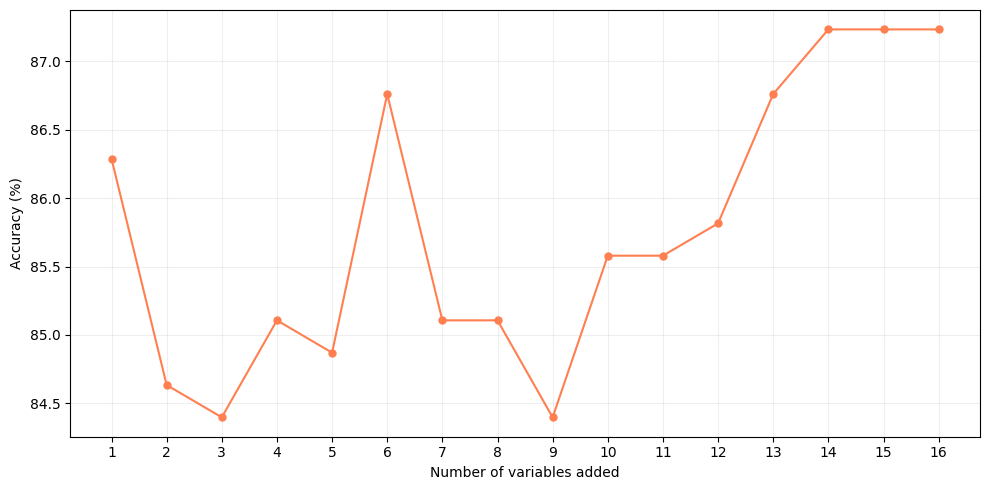

In [15]:



all_feats = X.columns.tolist()
n_features = len(all_feats)
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}

n_repeats = 1
all_curves = []

print("Random Variable Transformations + Accumulation\n")

for rep in range(n_repeats):
    np.random.seed()
    feat_order = np.random.permutation(all_feats).tolist()

    X_t = X.copy()
    feat_transforms = {}
    for feat in feat_order:
        tname = np.random.choice(list(transforms.keys())) if feat in num_cols else 'none'

        feat_transforms[feat] = tname
        if tname != 'none':
            X_t[feat] = transforms[tname](X_t[feat])

    X_t.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_t.fillna(0, inplace=True)

    Xt_train, Xt_test, yt_train, yt_test = train_test_split(
        X_t, y, test_size=0.2, random_state=42, stratify=y)

    accs = []
    print(f"Repeat {rep+1:2d}:")
    for k in range(1, n_features + 1):
        feats = feat_order[:k]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(Xt_train[feats], yt_train)
        acc = accuracy_score(yt_test, m.predict(Xt_test[feats])) * 100
        accs.append(acc)
        print(f"  Step {k:2d} | {feat_order[k-1]:35s} | {feat_transforms[feat_order[k-1]]:12s} | Acc: {acc:.2f}%")
    all_curves.append(accs)
    print()

all_curves = np.array(all_curves)
mean_curve = all_curves.mean(axis=0)

# Plot
feature_counts = np.arange(1, n_features + 1)

plt.figure(figsize=(10, 5))
for rep in range(n_repeats):
    plt.plot(feature_counts, all_curves[rep], marker="o", linewidth=1.5,
             markersize=5, color="coral")
plt.xlabel("Number of variables added")
plt.ylabel("Accuracy (%)")
plt.xticks(feature_counts)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

Random Variable Transformations + Accumulation

Repeat  1:
  Step  1 | TUE                                 | reciprocal   | Acc: 86.29%
  Step  2 | family_history_with_overweight      | square       | Acc: 86.29%
  Step  3 | FCVC                                | square       | Acc: 86.29%
  Step  4 | FAVC                                | none         | Acc: 86.52%
  Step  5 | CH2O                                | log          | Acc: 86.52%
  Step  6 | MTRANS                              | none         | Acc: 86.76%
  Step  7 | CALC                                | sqrt         | Acc: 87.00%
  Step  8 | SMOKE                               | sqrt         | Acc: 87.23%


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Step  9 | Weight                              | square       | Acc: 87.23%
  Step 10 | CAEC                                | log          | Acc: 87.00%
  Step 11 | Height                              | square       | Acc: 86.76%
  Step 12 | Gender                              | reciprocal   | Acc: 87.47%
  Step 13 | NCP                                 | log          | Acc: 87.71%
  Step 14 | FAF                                 | reciprocal   | Acc: 87.71%
  Step 15 | Age                                 | square       | Acc: 87.71%
  Step 16 | SCC                                 | log          | Acc: 87.71%



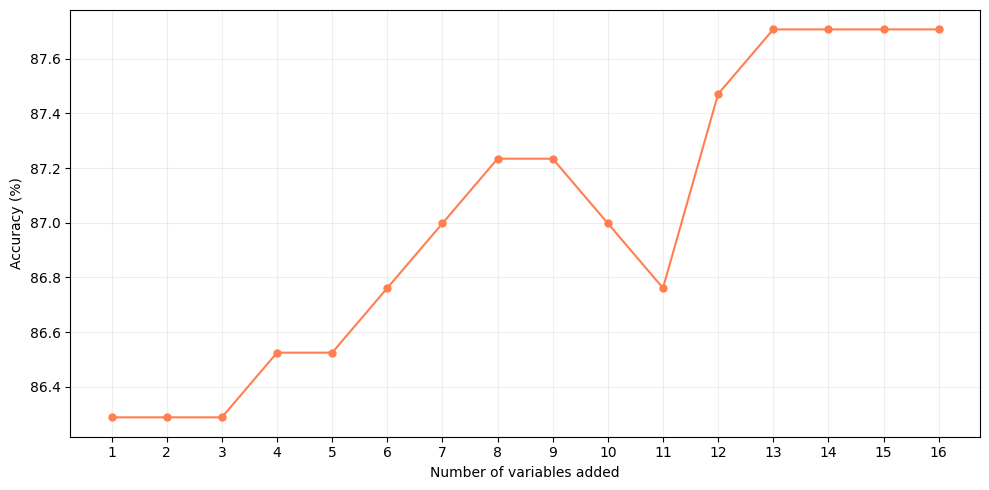

In [16]:
#

all_feats = X.columns.tolist()
n_features = len(all_feats)

transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}

n_repeats = 1
all_curves = []

print("Random Variable Transformations + Accumulation\n")

for rep in range(n_repeats):
    np.random.seed()
    feat_order = np.random.permutation(all_feats).tolist()

    X_t = X.copy()
    feat_transforms = {}
    for feat in feat_order:
        tname = np.random.choice(list(transforms.keys()))
        feat_transforms[feat] = tname
        X_t[feat] = transforms[tname](X_t[feat])

    X_t.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_t.fillna(0, inplace=True)

    Xt_train, Xt_test, yt_train, yt_test = train_test_split(
        X_t, y, test_size=0.2, random_state=42, stratify=y)

    accs = []
    print(f"Repeat {rep+1:2d}:")
    for k in range(1, n_features + 1):
        feats = feat_order[:k]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(Xt_train[feats], yt_train)
        acc = accuracy_score(yt_test, m.predict(Xt_test[feats])) * 100
        accs.append(acc)
        print(f"  Step {k:2d} | {feat_order[k-1]:35s} | {feat_transforms[feat_order[k-1]]:12s} | Acc: {acc:.2f}%")
    all_curves.append(accs)
    print()

all_curves = np.array(all_curves)
mean_curve = all_curves.mean(axis=0)

# Plot
feature_counts = np.arange(1, n_features + 1)

plt.figure(figsize=(10, 5))
for rep in range(n_repeats):
    plt.plot(feature_counts, all_curves[rep], marker="o", linewidth=1.5,
             markersize=5, color="coral")
plt.xlabel("Number of variables added")
plt.ylabel("Accuracy (%)")
plt.xticks(feature_counts)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

STEP 1 — Ranking within each group (before transformation)

  Easy (Demographic)
   1. family_history_with_overweight      | Acc: 86.29%
   2. Height                              | Acc: 86.29%
   3. Age                                 | Acc: 86.29%
   4. Gender                              | Acc: 86.29%
   5. Weight                              | Acc: 84.40%

  Mid (Simple Behavioral)
   1. CAEC                                | Acc: 86.52%
   2. CALC                                | Acc: 86.29%
   3. FAVC                                | Acc: 86.29%
   4. MTRANS                              | Acc: 86.29%
   5. SCC                                 | Acc: 86.29%
   6. SMOKE                               | Acc: 86.29%

  Complex (Estimation Behavioral)
   1. TUE                                 | Acc: 86.29%
   2. FAF                                 | Acc: 86.29%
   3. CH2O                                | Acc: 86.29%
   4. FCVC                                | Acc: 86.29%
   5. NCP        

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Step  3 | Age                                 | sqrt         | Acc: 86.29%
  Step  4 | Gender                              | square       | Acc: 86.29%
  Step  5 | Weight                              | sqrt         | Acc: 86.29%
  Step  6 | CAEC                                | sqrt         | Acc: 88.42%
  Step  7 | CALC                                | sqrt         | Acc: 88.42%
  Step  8 | FAVC                                | square       | Acc: 87.00%
  Step  9 | MTRANS                              | none         | Acc: 86.76%
  Step 10 | SCC                                 | none         | Acc: 86.76%
  Step 11 | SMOKE                               | none         | Acc: 88.42%
  Step 12 | TUE                                 | log          | Acc: 88.65%
  Step 13 | FAF                                 | sqrt         | Acc: 88.65%
  Step 14 | CH2O                                | none         | Acc: 88.42%
  Step 15 | FCVC                                | log          | Acc: 88.18%

/tmp/ipykernel_1149/3921833171.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


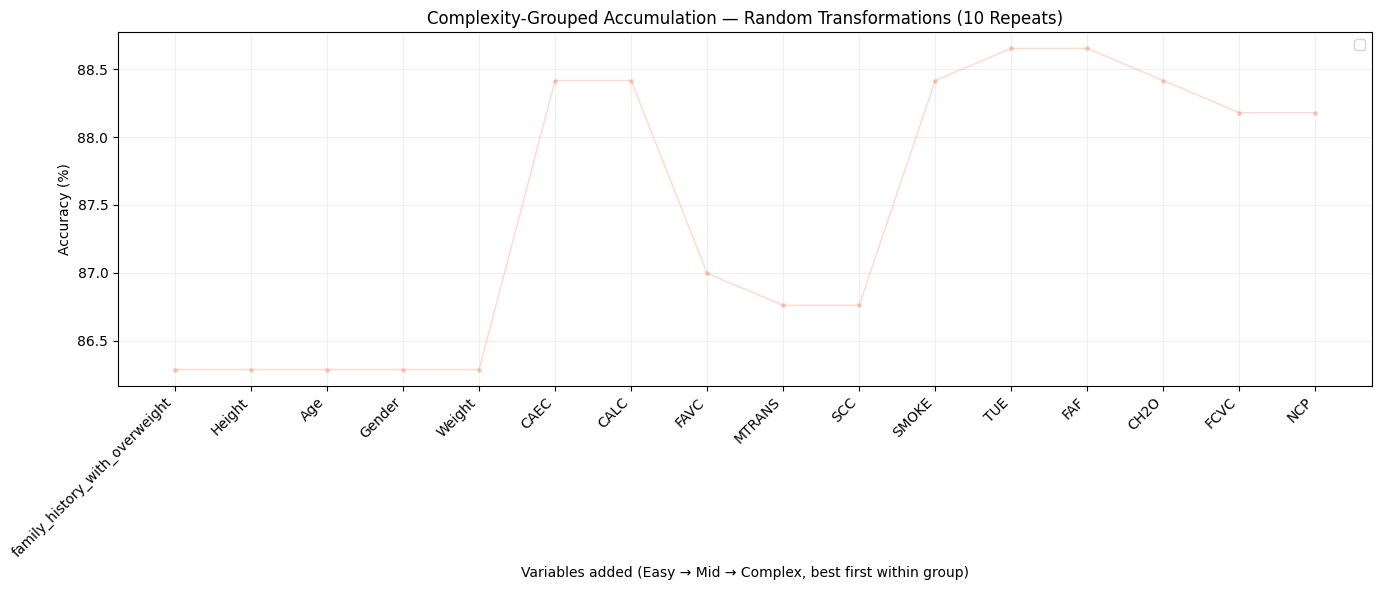

In [17]:


all_feats = X.columns.tolist()
n_features = len(all_feats)

easy = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight']
mid = ['SMOKE', 'SCC', 'MTRANS', 'FAVC', 'CAEC', 'CALC']
complex_vars = ['NCP', 'FCVC', 'CH2O', 'FAF', 'TUE']

groups = {
    'Easy (Demographic)': easy,
    'Mid (Simple Behavioral)': mid,
    'Complex (Estimation Behavioral)': complex_vars
}

group_colors = ['steelblue', 'coral', 'mediumseagreen']
transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}


print("STEP 1 — Ranking within each group (before transformation)\n")

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

group_ranked = {}
ordered_feats = []
ordered_groups = []

for group_idx, (group_name, variables) in enumerate(groups.items()):
    print(f"  {group_name}")
    names = []
    accs = []
    for feat in variables:
        scaler = StandardScaler()
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(scaler.fit_transform(X_train_split[[feat]]), y_train_split)
        acc = accuracy_score(y_test_split, m.predict(scaler.transform(X_test_split[[feat]]))) * 100
        names.append(feat)
        accs.append(acc)

    sorted_idx = np.argsort(accs)[::-1]
    sorted_names = [names[i] for i in sorted_idx]

    for rank, i in enumerate(sorted_idx, 1):
        print(f"  {rank:2d}. {names[i]:35s} | Acc: {accs[i]:.2f}%")

    group_ranked[group_name] = sorted_names
    ordered_feats.extend(sorted_names)
    ordered_groups.extend([group_idx] * len(sorted_names))
    print()


n_repeats = 1
all_curves = []


for rep in range(n_repeats):
    np.random.seed()

    # Assign random transformation to each variable
    X_t = X.copy()
    feat_transforms = {}
    for feat in ordered_feats:
        tname = np.random.choice(list(transforms.keys()))
        feat_transforms[feat] = tname
        X_t[feat] = transforms[tname](X_t[feat])

    X_t.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_t.fillna(0, inplace=True)

    Xt_train, Xt_test, yt_train, yt_test = train_test_split(
        X_t, y, test_size=0.2, random_state=42, stratify=y)

    accs = []
    selected = []
    print(f"Repeat {rep+1:2d}:")
    for k in range(n_features):
        feat = ordered_feats[k]
        selected.append(feat)
        scaler = StandardScaler()
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(scaler.fit_transform(Xt_train[selected]), yt_train)
        acc = accuracy_score(yt_test, m.predict(scaler.transform(Xt_test[selected]))) * 100
        accs.append(acc)
        print(f"  Step {k+1:2d} | {feat:35s} | {feat_transforms[feat]:12s} | Acc: {acc:.2f}%")
    all_curves.append(accs)
    print()

all_curves = np.array(all_curves)
mean_curve = all_curves.mean(axis=0)


#
x = np.arange(1, n_features + 1)

plt.figure(figsize=(14, 6))


for rep in range(n_repeats):
    plt.plot(x, all_curves[rep], marker=".", linewidth=1, markersize=5,
             color="coral", alpha=0.3)



plt.xticks(x, ordered_feats, rotation=45, ha="right")
plt.xlabel("Variables added (Easy → Mid → Complex, best first within group)")
plt.ylabel("Accuracy (%)")
plt.title("Complexity-Grouped Accumulation — Random Transformations (10 Repeats)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()



STAGE 1: Selecting best transformation per variable
  Age                            -> none          (single-feat acc: 86.29%)
  Height                         -> none          (single-feat acc: 86.29%)
  Weight                         -> reciprocal    (single-feat acc: 87.23%)
  FCVC                           -> none          (single-feat acc: 86.29%)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = 

  NCP                            -> none          (single-feat acc: 86.29%)
  CH2O                           -> none          (single-feat acc: 86.29%)
  FAF                            -> none          (single-feat acc: 86.29%)
  TUE                            -> none          (single-feat acc: 86.29%)

STAGE 2: Cumulative feature addition (random order)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = 

  Repeat  1 | final acc: 86.29%


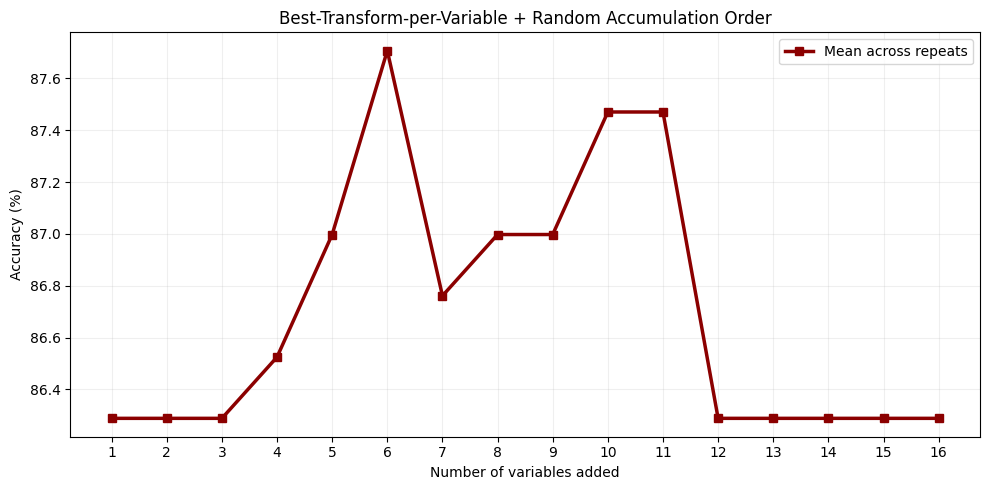


Final transform choices:
  Gender                         -> none
  Age                            -> none
  Height                         -> none
  Weight                         -> reciprocal
  family_history_with_overweight -> none
  FAVC                           -> none
  FCVC                           -> none
  NCP                            -> none
  CAEC                           -> none
  SMOKE                          -> none
  CH2O                           -> none
  SCC                            -> none
  FAF                            -> none
  TUE                            -> none
  CALC                           -> none
  MTRANS                         -> none


In [18]:


all_feats = X.columns.tolist()
n_features = len(all_feats)
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}

\
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_transforms = {}

print("=" * 65)
print("STAGE 1: Selecting best transformation per variable")
print("=" * 65)

for feat in all_feats:
    if feat not in num_cols:
        best_transforms[feat] = 'none'
        continue

    best_acc = -1
    best_tname = 'none'

    for tname, tfunc in transforms.items():
        try:
            col_train = tfunc(X_base_train[[feat]].copy()[feat])
            col_test  = tfunc(X_base_test[[feat]].copy()[feat])

            col_train = col_train.replace([np.inf, -np.inf], np.nan).fillna(0)
            col_test  = col_test.replace([np.inf, -np.inf], np.nan).fillna(0)

            m = LogisticRegression(max_iter=1000, random_state=42)
            m.fit(col_train.values.reshape(-1, 1), y_train)
            acc = accuracy_score(y_test, m.predict(col_test.values.reshape(-1, 1)))

            if acc > best_acc:
                best_acc = acc
                best_tname = tname
        except Exception:
            continue

    best_transforms[feat] = best_tname
    print(f"  {feat:30s} -> {best_tname:12s}  (single-feat acc: {best_acc*100:.2f}%)")

print()


X_best = X.copy()
for feat, tname in best_transforms.items():
    if tname != 'none':
        X_best[feat] = transforms[tname](X_best[feat])

X_best.replace([np.inf, -np.inf], np.nan, inplace=True)
X_best.fillna(0, inplace=True)


n_repeats = 1
all_curves = []

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 65)
print("STAGE 2: Cumulative feature addition (random order)")
print("=" * 65)

for rep in range(n_repeats):
    np.random.seed()
    feat_order = np.random.permutation(all_feats).tolist()

    accs = []
    for k in range(1, n_features + 1):
        feats = feat_order[:k]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(Xb_train[feats], yb_train)
        acc = accuracy_score(yb_test, m.predict(Xb_test[feats])) * 100
        accs.append(acc)
    all_curves.append(accs)
    print(f"  Repeat {rep+1:2d} | final acc: {accs[-1]:.2f}%")

all_curves = np.array(all_curves)
mean_curve = all_curves.mean(axis=0)


feature_counts = np.arange(1, n_features + 1)

plt.figure(figsize=(10, 5))
for rep in range(n_repeats):
    plt.plot(feature_counts, all_curves[rep], marker="o", linewidth=0.8,
             markersize=4, color="coral", alpha=0.3)
plt.plot(feature_counts, mean_curve, marker="s", linewidth=2.5,
         markersize=6, color="darkred", label="Mean across repeats")
plt.xlabel("Number of variables added")
plt.ylabel("Accuracy (%)")
plt.title("Best-Transform-per-Variable + Random Accumulation Order")
plt.xticks(feature_counts)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\nFinal transform choices:")
for feat, tname in best_transforms.items():
    print(f"  {feat:30s} -> {tname}")

STAGE 1: Selecting best transformation per variable
  Gender                              -> none          (single-feat acc: 86.29%)
  Age                                 -> none          (single-feat acc: 86.29%)
  Height                              -> none          (single-feat acc: 86.29%)
  Weight                              -> reciprocal    (single-feat acc: 87.23%)
  family_history_with_overweight      -> none          (single-feat acc: 86.29%)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = g

  FAVC                                -> none          (single-feat acc: 86.29%)
  FCVC                                -> none          (single-feat acc: 86.29%)
  NCP                                 -> none          (single-feat acc: 86.29%)
  CAEC                                -> none          (single-feat acc: 86.52%)
  SMOKE                               -> none          (single-feat acc: 86.29%)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = g

  CH2O                                -> none          (single-feat acc: 86.29%)
  SCC                                 -> none          (single-feat acc: 86.29%)
  FAF                                 -> none          (single-feat acc: 86.29%)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


  TUE                                 -> none          (single-feat acc: 86.29%)
  CALC                                -> none          (single-feat acc: 86.29%)
  MTRANS                              -> none          (single-feat acc: 86.29%)

STAGE 2: Cumulative feature addition (random order)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)



  Repeat 1 details:
    Step  1 | Gender                              | none         | Acc: 86.29%
    Step  2 | FAVC                                | none         | Acc: 86.29%
    Step  3 | Age                                 | none         | Acc: 86.29%
    Step  4 | Height                              | none         | Acc: 86.52%
    Step  5 | family_history_with_overweight      | none         | Acc: 86.52%
    Step  6 | MTRANS                              | none         | Acc: 86.52%
    Step  7 | NCP                                 | none         | Acc: 87.23%
    Step  8 | TUE                                 | none         | Acc: 87.23%
    Step  9 | Weight                              | reciprocal   | Acc: 87.71%
    Step 10 | CAEC                                | none         | Acc: 87.47%
    Step 11 | FCVC                                | none         | Acc: 87.00%
    Step 12 | FAF                                 | none         | Acc: 87.00%
    Step 13 | SMOKE            

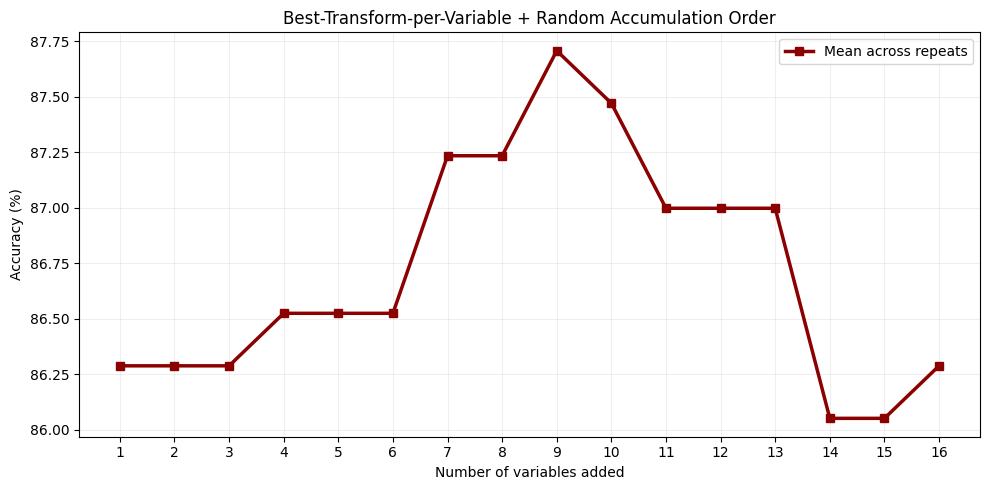


Final transform choices:
  Gender                              -> none
  Age                                 -> none
  Height                              -> none
  Weight                              -> reciprocal
  family_history_with_overweight      -> none
  FAVC                                -> none
  FCVC                                -> none
  NCP                                 -> none
  CAEC                                -> none
  SMOKE                               -> none
  CH2O                                -> none
  SCC                                 -> none
  FAF                                 -> none
  TUE                                 -> none
  CALC                                -> none
  MTRANS                              -> none


In [19]:



all_feats = X.columns.tolist()
n_features = len(all_feats)
transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}


X_base_train, X_base_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_transforms = {}

print("=" * 65)
print("STAGE 1: Selecting best transformation per variable")
print("=" * 65)

for feat in all_feats:
    best_acc = -1
    best_tname = 'log'  # fallback default

    for tname, tfunc in transforms.items():
        try:
            col_train = tfunc(X_base_train[feat].copy())
            col_test  = tfunc(X_base_test[feat].copy())

            col_train = col_train.replace([np.inf, -np.inf], np.nan).fillna(0)
            col_test  = col_test.replace([np.inf, -np.inf], np.nan).fillna(0)

            m = LogisticRegression(max_iter=1000, random_state=42)
            m.fit(col_train.values.reshape(-1, 1), y_train)
            acc = accuracy_score(y_test, m.predict(col_test.values.reshape(-1, 1)))

            if acc > best_acc:
                best_acc = acc
                best_tname = tname
        except Exception:
            continue

    best_transforms[feat] = best_tname
    print(f"  {feat:35s} -> {best_tname:12s}  (single-feat acc: {best_acc*100:.2f}%)")

print()


X_best = X.copy()
for feat, tname in best_transforms.items():
    X_best[feat] = transforms[tname](X_best[feat])

X_best.replace([np.inf, -np.inf], np.nan, inplace=True)
X_best.fillna(0, inplace=True)


n_repeats = 1
all_curves = []

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 65)
print("STAGE 2: Cumulative feature addition (random order)")
print("=" * 65)

for rep in range(n_repeats):
    np.random.seed()
    feat_order = np.random.permutation(all_feats).tolist()

    accs = []
    for k in range(1, n_features + 1):
        feats = feat_order[:k]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(Xb_train[feats], yb_train)
        acc = accuracy_score(yb_test, m.predict(Xb_test[feats])) * 100
        accs.append(acc)
    all_curves.append(accs)

    # Print details for first repeat only
    if rep == 0:
        print(f"\n  Repeat {rep+1} details:")
        for k in range(n_features):
            f = feat_order[k]
            print(f"    Step {k+1:2d} | {f:35s} | {best_transforms[f]:12s} | Acc: {accs[k]:.2f}%")
    else:
        print(f"  Repeat {rep+1:2d} | final acc: {accs[-1]:.2f}%")

all_curves = np.array(all_curves)
mean_curve = all_curves.mean(axis=0)


feature_counts = np.arange(1, n_features + 1)

plt.figure(figsize=(10, 5))
for rep in range(n_repeats):
    plt.plot(feature_counts, all_curves[rep], marker="o", linewidth=0.8,
             markersize=4, color="coral", alpha=0.3)
plt.plot(feature_counts, mean_curve, marker="s", linewidth=2.5,
         markersize=6, color="darkred", label="Mean across repeats")
plt.xlabel("Number of variables added")
plt.ylabel("Accuracy (%)")
plt.title("Best-Transform-per-Variable + Random Accumulation Order")
plt.xticks(feature_counts)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Summary
print("\nFinal transform choices:")
for feat, tname in best_transforms.items():
    print(f"  {feat:35s} -> {tname}")

STEP 1 — Ranking within each group (before transformation)

  Easy (Demographic)
   1. family_history_with_overweight      | Acc: 86.29%
   2. Height                              | Acc: 86.29%
   3. Age                                 | Acc: 86.29%
   4. Gender                              | Acc: 86.29%
   5. Weight                              | Acc: 84.40%

  Mid (Simple Behavioral)
   1. CAEC                                | Acc: 86.52%
   2. CALC                                | Acc: 86.29%
   3. FAVC                                | Acc: 86.29%
   4. MTRANS                              | Acc: 86.29%
   5. SCC                                 | Acc: 86.29%
   6. SMOKE                               | Acc: 86.29%

  Complex (Estimation Behavioral)
   1. TUE                                 | Acc: 86.29%
   2. FAF                                 | Acc: 86.29%
   3. CH2O                                | Acc: 86.29%
   4. FCVC                                | Acc: 86.29%
   5. NCP        

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


  family_history_with_overweight      -> none          (acc: 86.29%)
  Height                              -> none          (acc: 86.29%)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Age                                 -> none          (acc: 86.29%)
  Gender                              -> none          (acc: 86.29%)


...

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = g

  CH2O                                -> none          (acc: 86.29%)
  FCVC                                -> none          (acc: 86.29%)
  NCP                                 -> none          (acc: 86.29%)

STEP 3 — Cumulative accumulation (Easy → Mid → Complex)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Step  1 | family_history_with_overweight      | none         | Acc: 86.29%
  Step  2 | Height                              | none         | Acc: 86.29%
  Step  3 | Age                                 | none         | Acc: 86.29%
  Step  4 | Gender                              | none         | Acc: 86.29%
  Step  5 | Weight                              | reciprocal   | Acc: 86.76%
  Step  6 | CAEC                                | none         | Acc: 86.52%
  Step  7 | CALC                                | none         | Acc: 86.52%
  Step  8 | FAVC                                | none         | Acc: 86.52%
  Step  9 | MTRANS                              | none         | Acc: 86.52%
  Step 10 | SCC                                 | none         | Acc: 86.76%
  Step 11 | SMOKE                               | none         | Acc: 86.52%
  Step 12 | TUE                                 | none         | Acc: 86.52%
  Step 13 | FAF                                 | none         | Acc: 87.00%

/tmp/ipykernel_1149/1835943305.py:147: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


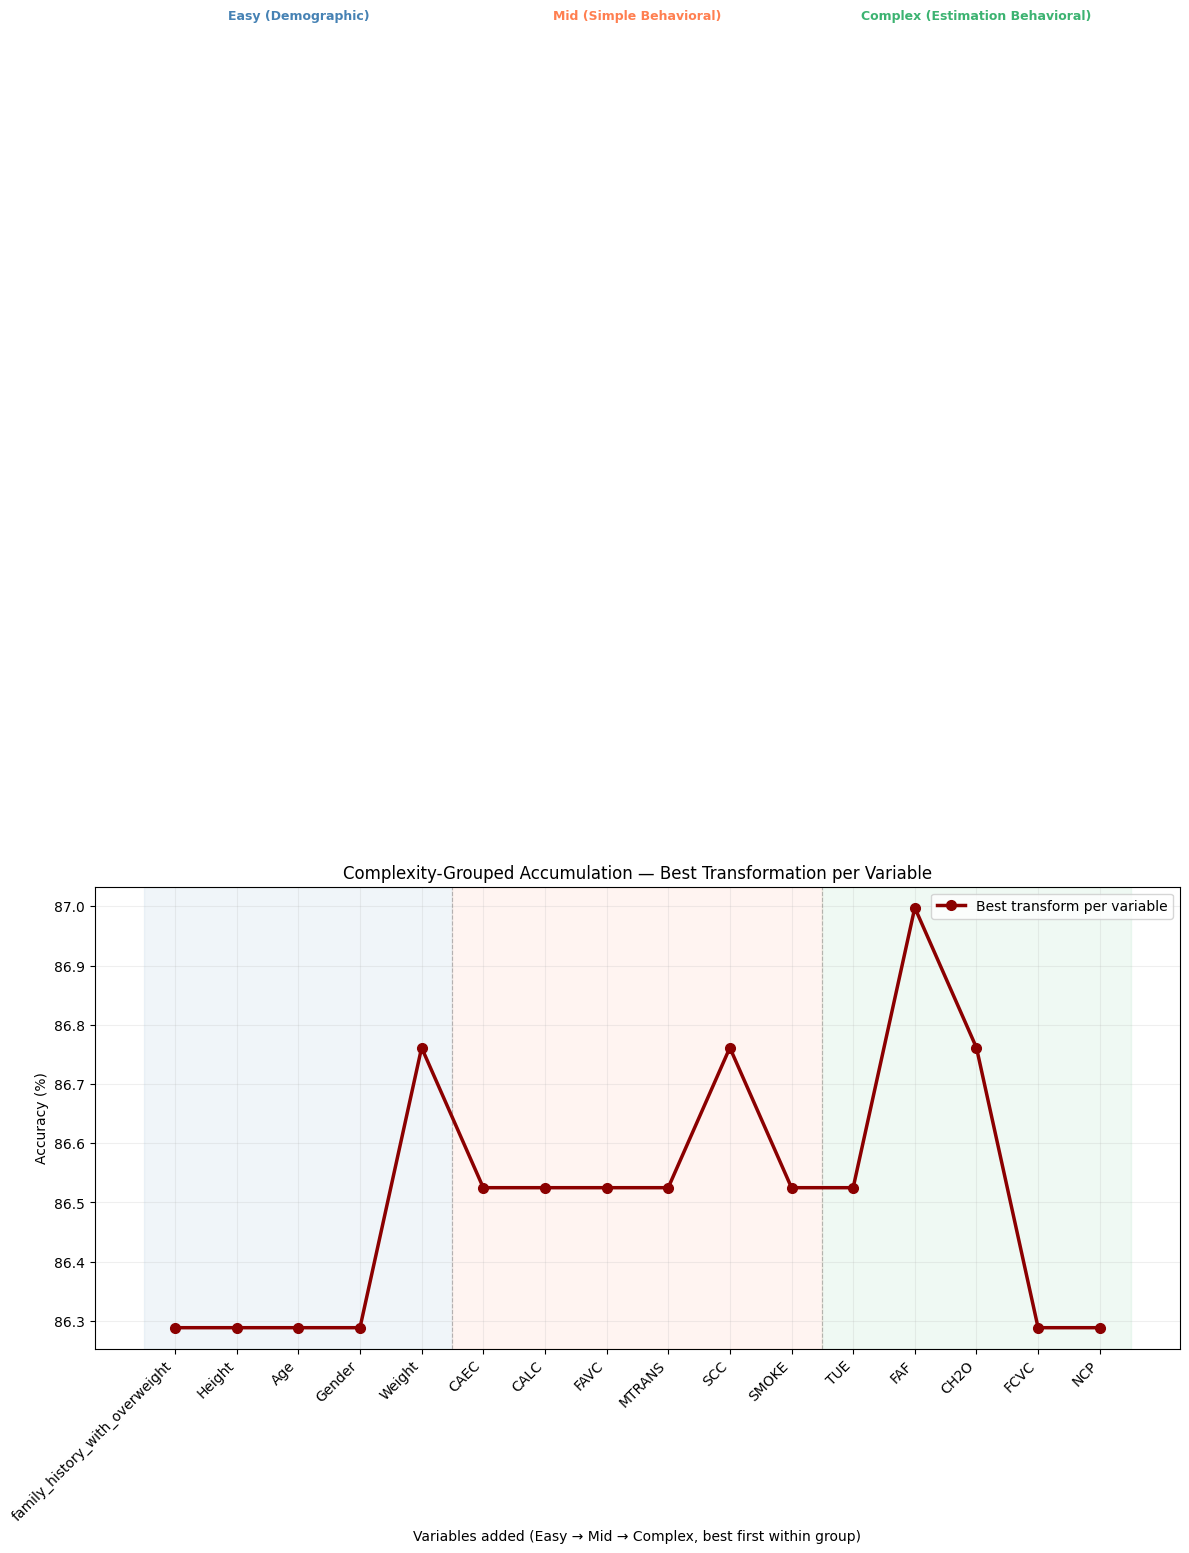


Final transform choices:
  family_history_with_overweight      -> none
  Height                              -> none
  Age                                 -> none
  Gender                              -> none
  Weight                              -> reciprocal
  CAEC                                -> none
  CALC                                -> none
  FAVC                                -> none
  MTRANS                              -> none
  SCC                                 -> none
  SMOKE                               -> none
  TUE                                 -> none
  FAF                                 -> none
  CH2O                                -> none
  FCVC                                -> none
  NCP                                 -> none


In [20]:


all_feats = X.columns.tolist()
n_features = len(all_feats)

easy = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight']
mid = ['SMOKE', 'SCC', 'MTRANS', 'FAVC', 'CAEC', 'CALC']
complex_vars = ['NCP', 'FCVC', 'CH2O', 'FAF', 'TUE']

groups = {
    'Easy (Demographic)': easy,
    'Mid (Simple Behavioral)': mid,
    'Complex (Estimation Behavioral)': complex_vars
}

group_colors = ['steelblue', 'coral', 'mediumseagreen']
transforms = {
    'none':        lambda x: x,
    'log':         lambda x: np.log1p(x),
    'sqrt':        lambda x: np.sqrt(x),
    'square':      lambda x: x ** 2,
    'reciprocal':  lambda x: 1 / (x + 1),
    'standardize': lambda x: (x - x.mean()) / x.std()
}
\
print("STEP 1 — Ranking within each group (before transformation)\n")

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

group_ranked = {}
ordered_feats = []
ordered_groups = []

for group_idx, (group_name, variables) in enumerate(groups.items()):
    print(f"  {group_name}")
    names = []
    accs = []
    for feat in variables:
        scaler = StandardScaler()
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(scaler.fit_transform(X_train_split[[feat]]), y_train_split)
        acc = accuracy_score(y_test_split, m.predict(scaler.transform(X_test_split[[feat]]))) * 100
        names.append(feat)
        accs.append(acc)

    sorted_idx = np.argsort(accs)[::-1]
    sorted_names = [names[i] for i in sorted_idx]

    for rank, i in enumerate(sorted_idx, 1):
        print(f"  {rank:2d}. {names[i]:35s} | Acc: {accs[i]:.2f}%")

    group_ranked[group_name] = sorted_names
    ordered_feats.extend(sorted_names)
    ordered_groups.extend([group_idx] * len(sorted_names))
    print()


print("=" * 65)
print("STEP 2 — Selecting best transformation per variable")
print("=" * 65)

best_transforms = {}

for feat in ordered_feats:
    best_acc = -1
    best_tname = 'log'  # fallback

    for tname, tfunc in transforms.items():
        try:
            col_train = tfunc(X_train_split[feat].copy())
            col_test  = tfunc(X_test_split[feat].copy())

            col_train = col_train.replace([np.inf, -np.inf], np.nan).fillna(0)
            col_test  = col_test.replace([np.inf, -np.inf], np.nan).fillna(0)

            scaler = StandardScaler()
            m = LogisticRegression(max_iter=1000, random_state=42)
            m.fit(scaler.fit_transform(col_train.values.reshape(-1, 1)), y_train_split)
            acc = accuracy_score(y_test_split,
                                 m.predict(scaler.transform(col_test.values.reshape(-1, 1))))

            if acc > best_acc:
                best_acc = acc
                best_tname = tname
        except Exception:
            continue

    best_transforms[feat] = best_tname
    print(f"  {feat:35s} -> {best_tname:12s}  (acc: {best_acc*100:.2f}%)")

print()


X_best = X.copy()
for feat, tname in best_transforms.items():
    X_best[feat] = transforms[tname](X_best[feat])

X_best.replace([np.inf, -np.inf], np.nan, inplace=True)
X_best.fillna(0, inplace=True)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y)

print("=" * 65)
print("STEP 3 — Cumulative accumulation (Easy → Mid → Complex)")
print("=" * 65)

accs = []
selected = []
for k in range(n_features):
    feat = ordered_feats[k]
    selected.append(feat)
    scaler = StandardScaler()
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(scaler.fit_transform(Xb_train[selected]), yb_train)
    acc = accuracy_score(yb_test, m.predict(scaler.transform(Xb_test[selected]))) * 100
    accs.append(acc)
    print(f"  Step {k+1:2d} | {feat:35s} | {best_transforms[feat]:12s} | Acc: {acc:.2f}%")

accs = np.array(accs)


x = np.arange(1, n_features + 1)

plt.figure(figsize=(14, 6))

prev_end = 0
for group_idx, (group_name, variables) in enumerate(groups.items()):
    start = prev_end
    end = start + len(group_ranked[group_name])
    mid_point = (start + end) / 2 + 0.5
    plt.axvspan(start + 0.5, end + 0.5, alpha=0.08, color=group_colors[group_idx])
    plt.text(mid_point, accs.max() + 1.5, group_name, ha="center",
             fontsize=9, fontweight="bold", color=group_colors[group_idx])
    if start > 0:
        plt.axvline(x=start + 0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    prev_end = end

plt.plot(x, accs, marker="o", linewidth=2.5, markersize=7,
         color="darkred", label="Best transform per variable", zorder=5)

plt.xticks(x, ordered_feats, rotation=45, ha="right")
plt.xlabel("Variables added (Easy → Mid → Complex, best first within group)")
plt.ylabel("Accuracy (%)")
plt.title("Complexity-Grouped Accumulation — Best Transformation per Variable")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Summary
print("\nFinal transform choices:")
for feat, tname in best_transforms.items():
    print(f"  {feat:35s} -> {tname}")

Bootstrapping baseline with SMOTE (100 iterations)...

BOOTSTRAPPED BASELINE RESULTS (with SMOTE)
  Accuracy    : 80.42%   (95% CI: 77.41% - 82.88%)
  Sensitivity : 83.63%   (95% CI: 75.11% - 91.63%)
  Specificity : 79.92%   (95% CI: 77.00% - 82.95%)
  F1-Score    : 53.61%   (95% CI: 47.18% - 58.89%)


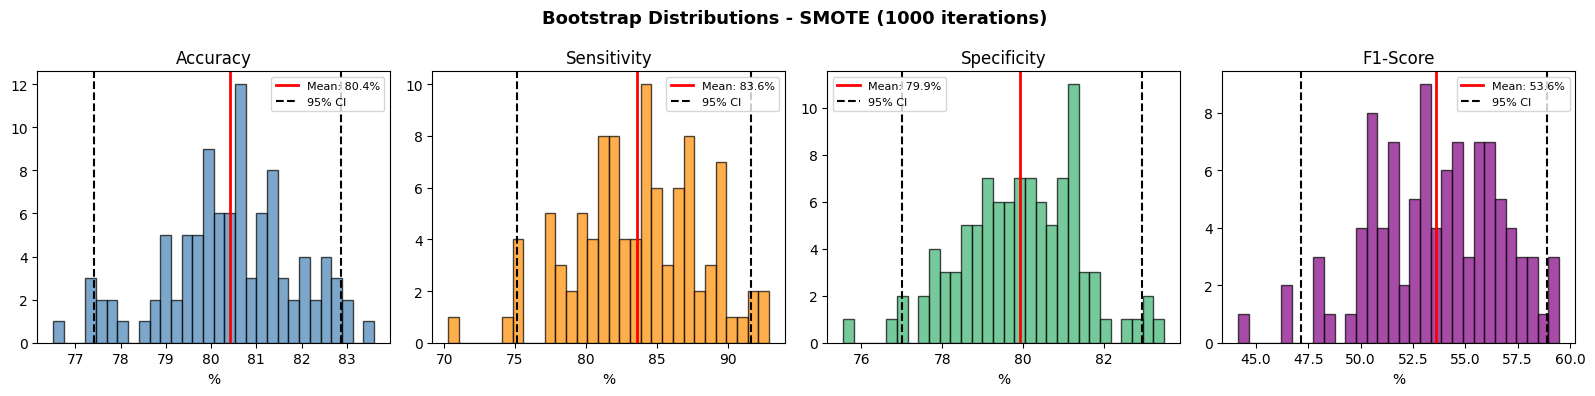

In [21]:
#bootstrap
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt

n_bootstrap =100

boot_acc  = []
boot_sens = []
boot_spec = []
boot_f1   = []

print(f"Bootstrapping baseline with SMOTE ({n_bootstrap} iterations)...\n")

for b in range(n_bootstrap):
    X_boot, y_boot = resample(X, y, random_state=b, stratify=y)

    boot_idx = set(X_boot.index)
    oob_mask = ~X.index.isin(boot_idx)
    X_oob = X[oob_mask]
    y_oob = y[oob_mask]

    if len(y_oob) < 10 or y_oob.nunique() < 2:
        continue

    smote = SMOTE(random_state=42, k_neighbors=5)
    X_boot_sm, y_boot_sm = smote.fit_resample(X_boot, y_boot)

    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_boot_sm, y_boot_sm)
    y_pred = m.predict(X_oob)

    acc, sens, spec, f1 = compute_metrics(y_oob, y_pred)
    boot_acc.append(acc)
    boot_sens.append(sens)
    boot_spec.append(spec)
    boot_f1.append(f1)

boot_acc  = np.array(boot_acc)
boot_sens = np.array(boot_sens)
boot_spec = np.array(boot_spec)
boot_f1   = np.array(boot_f1)

print("=" * 65)
print("BOOTSTRAPPED BASELINE RESULTS (with SMOTE)")
print("=" * 65)
print(f"  Accuracy    : {boot_acc.mean():.2f}%   (95% CI: {np.percentile(boot_acc, 2.5):.2f}% - {np.percentile(boot_acc, 97.5):.2f}%)")
print(f"  Sensitivity : {boot_sens.mean():.2f}%   (95% CI: {np.percentile(boot_sens, 2.5):.2f}% - {np.percentile(boot_sens, 97.5):.2f}%)")
print(f"  Specificity : {boot_spec.mean():.2f}%   (95% CI: {np.percentile(boot_spec, 2.5):.2f}% - {np.percentile(boot_spec, 97.5):.2f}%)")
print(f"  F1-Score    : {boot_f1.mean():.2f}%   (95% CI: {np.percentile(boot_f1, 2.5):.2f}% - {np.percentile(boot_f1, 97.5):.2f}%)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, data, name, color in zip(axes,
    [boot_acc, boot_sens, boot_spec, boot_f1],
    ['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score'],
    ['steelblue', 'darkorange', 'mediumseagreen', 'purple']):
    ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linewidth=2, label=f'Mean: {data.mean():.1f}%')
    ax.axvline(np.percentile(data, 2.5), color='black', linestyle='--', label='95% CI')
    ax.axvline(np.percentile(data, 97.5), color='black', linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('%')
    ax.legend(fontsize=8)
plt.suptitle('Bootstrap Distributions - SMOTE (1000 iterations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()